# Class 6 - Advanced Python

Today we learn to write our own **functions**, turn notebook workflows into **scripts**, solve a simple differential equation with the **Euler method**, and **measure** how fast our code runs.

Goals:
- define and call your own Python functions (`def`, parameters, `return`),
- refactor notebook workflows from Classes 4 and 5 into reusable scripts,
- solve a first-order ODE with the Euler method,
- compare loop vs vectorised performance with `time.perf_counter()`.

In [1]:
import numpy as np

## 1. Creating functions

In **Class 3b**, you checked whether wind was calm enough for an outdoor art performance. Station data often report wind in **m/s**, while weather reports use **km/h**. If you only had two readings, copy-pasting the formula is fine:

```python
wind_kmh1 = wind_ms1 * 3.6
wind_kmh2 = wind_ms2 * 3.6
```

But repeating the same logic many times makes code long and hard to maintain. A **function** packages instructions into a reusable block. You **define** it once, then **call** it whenever you need it.

### i. Repetitive code

Three wind readings in m/s — convert each one to km/h by hand:

In [2]:
WindMs1 = 2.5
WindMs2 = 4.0
WindMs3 = 5.8
WindKmh1 = WindMs1 * 3.6
WindKmh2 = WindMs2 * 3.6
WindKmh3 = WindMs3 * 3.6
print(WindKmh1, WindKmh2, WindKmh3)

9.0 14.4 20.88


### ii. Defining a function with `def` and `return`

Function syntax:

```py
def function_name(function_parameter1, function_parameter2):
    function_body
    return function_return1, function_return2
```

Use `return` to send a result back to the caller.

In [3]:
def ms_to_kmh(speed_ms):
    speed_kmh = speed_ms * 3.6
    return speed_kmh

In [4]:
ms_to_kmh(10)

36.0

In [5]:
WindKmh1 = ms_to_kmh(WindMs1)
WindKmh2 = ms_to_kmh(WindMs2)
WindKmh3 = ms_to_kmh(WindMs3)
print(WindKmh1, WindKmh2, WindKmh3)

9.0 14.4 20.88


You can also combine in with a loop to get nirvana optimization! 🎸

In [6]:
for sta in [WindMs1, WindMs2, WindMs3]:
    print(ms_to_kmh(sta))

9.0
14.4
20.88


### iii. Variable scope

Variables created **inside** a function are **local**: they disappear when the function finishes. If you try to use them outside, Python raises a `NameError`.

In [7]:
def demo_scope(speed_ms):
    speed_kmh_local = ms_to_kmh(speed_ms)
    return speed_kmh_local
speed_kmh = demo_scope(4.0)

Try to solve the code above:

## Exercise A

This exercise is a copy of **Class 3b Exercise A**, except that you must wrap the conversion in a function.

To find the best location to plant a temperature-sensitive species in your garden, you measure the temperature at five different locations. The numbers you read on your thermometer are: 20.4°C, 20.8°C, 21.1°C, 20.3°C, and 21.2°C.

Your American cousin, an avid gardener, comes to visit you and doesn't understand degrees Celsius. Convert all temperature measures to degrees Fahrenheit. Display the averages in both units.

In [8]:
def celsius_to_fahrenheit(temp_c):
    return temp_c * 9 / 5 + 32
TempGardenC = np.array([20.4, 20.8, 21.1, 20.3, 21.2])
NObs = np.size(TempGardenC)
TempGardenF = np.zeros(NObs)
for i in range(NObs):
    TempGardenF[i] = celsius_to_fahrenheit(TempGardenC[i])
print(f'Average (°C): {np.mean(TempGardenC):.2f}')
print(f'Average (°F): {np.mean(TempGardenF):.2f}')

Average (°C): 20.76
Average (°F): 69.37


## Exercise B

After your garden open day, visitors rate their experience on a **Likert scale** (from Poor to Excellent). You ran two tours, morning and afternoon, and want to compare them.

Unfortunately, a volunteer took notes but sometimes recorded a number by mistake instead of the scale value. Every response counts: your function must handle **both** formats.

Tasks:
1. Write `encode_feedback(feedback, code_map)` that takes a **whole array** of responses and returns an array of numbers. 
2. Call it once for the morning group and once for the afternoon group.
3. Print the mean score of each tour and compare them.

> **Tip:** use `if feedback[i] in code_map` to tell the two cases apart

In [9]:
MorningFeedback = np.array(['Good', 'Very good', '4', 'Poor', 'Excellent', 'Very good', 'Good', '5', 'Excellent', 'Fair', 'Very good', '3'])
AfternoonFeedback = np.array(['2', 'Fair', 'Good', '3', 'Very good', 'Good', 'Excellent', 'Poor', 'Fair', '1', 'Fair', '2'])
CodeMap = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Very good': 4, 'Excellent': 5}

def encode_feedback(feedback, code_map):
    NObs = np.size(feedback)
    Codes = np.zeros(NObs)
    for i in range(NObs):
        if feedback[i] in code_map:
            Codes[i] = code_map[feedback[i]]
        else:
            Codes[i] = int(feedback[i])
    return Codes
MorningCodes = encode_feedback(feedback=MorningFeedback, code_map=CodeMap)
AfternoonCodes = encode_feedback(feedback=AfternoonFeedback, code_map=CodeMap)
print(MorningCodes)
print(AfternoonCodes)
print(f'Morning mean:   {np.mean(MorningCodes):.2f}')
print(f'Afternoon mean: {np.mean(AfternoonCodes):.2f}')

[3. 4. 4. 1. 5. 4. 3. 5. 5. 2. 4. 3.]
[2. 2. 3. 3. 4. 3. 5. 1. 2. 1. 2. 2.]
Morning mean:   3.58
Afternoon mean: 2.50


## 2. Functions on real data (Classes 4 & 5 recap)

In **Class 4**, you wrote `add_fahrenheit_column(df, celsius_col)` to convert a Pandas column for your American cousin. In **Class 5a**, you wrote `celsius_to_fahrenheit_da(temp_da)` for an xarray DataArray.

The conversion formula is always the same — only the **data container** changes (NumPy array, Pandas column, xarray DataArray). In this class you learned the general idea behind those functions: define once with `def`, call many times.

## 3. From notebook to script: Class 5a `post-processing.py`

In **Class 5a**, you analysed gridded temperature data step by step in a notebook. For reproducibility, the same workflow can live in a **Python script** that anyone can run from the terminal:

```bash
python post-processing.py
```

Open [`post-processing.py`](post-processing.py) in VS Code. It contains the Class 5a pipeline:

1. Open netCDF and extract `pred_temperature_C`
2. Hartheim point series
3. Freiburg box → spatial mean → daily resample
4. Value mask (`Temp > 5`)
5. Urban heat island stats (**Exercise D** from Class 5a)

Each step is already a small function (`load_temperature`, `freiburg_box`, `spatial_mean_series`, …). Run the script:

In [10]:
%run post-processing.py

=== Class 5a post-processing ===



Opened: pred_temperature_C_2024_01_wgs84.nc
  dims: ('time', 'lat', 'lon'), shape: (744, 2132, 1701)



Hartheim January mean: 2.74 °C


Freiburg box spatial mean (first day): 4.24 °C


Freiburg box spatial mean (last day):  5.87 °C



Cells warmer than 5 °C (all timesteps): 407,670,240



Urban heat island (city − countryside > 1 °C):
  Hours: 305 / 744
  Share: 41.0 %


## Exercise D — Multiple netCDF files

In research you rarely have a single file. What changes if you receive **several monthly netCDF files** (same variable, same grid)?

Tasks:
1. Think: which parts of `post-processing.py` should become a reusable function?
2. Write `process_netcdf(path, city_mask_path)` that returns a summary dict with:
   - file path,
   - Hartheim mean temperature (°C),
   - daily spatial-mean series over the Freiburg box,
   - urban heat island stats (hours and % with city − countryside > 1 °C).
3. Loop over a list of paths and collect the results.

For practice, we split January into two halves (no extra data download needed). The instructor solution is in [`post-processing_solution.py`](post-processing_solution.py).

In [11]:
from pathlib import Path
ChunkDir = Path('_exercise_chunks')
ChunkDir.mkdir(exist_ok=True)
TempDs = xr.open_dataset('../../processed_data/pred_temperature_C_2024_01_wgs84.nc')
TempDs.sel(time=slice('2024-01-01', '2024-01-15')).to_netcdf(ChunkDir / 'jan_2024_part1.nc')
TempDs.sel(time=slice('2024-01-16', '2024-01-31')).to_netcdf(ChunkDir / 'jan_2024_part2.nc')
TempDs.close()
print('Created', list(ChunkDir.glob('*.nc')))

PermissionError: [Errno 13] Permission denied: '/Users/damseaux-a/Documents/FuFo/coding_course/coding-course/solutions/06-advanced-python/_exercise_chunks/jan_2024_part1.nc'

In [12]:
# Solution — see post-processing_solution.py for the full version
%run post-processing_solution.py

PermissionError: [Errno 13] Permission denied: '/Users/damseaux-a/Documents/FuFo/coding_course/coding-course/solutions/06-advanced-python/_exercise_chunks/jan_2024_part1.nc'

## 4. Same pattern for Class 4: `station-processing.py`

The same idea applies to **tabular** data from **Class 4**. Open [`station-processing.py`](station-processing.py): it loads the Hartheim CSV, selects columns, adds a gradient column, counts hot hours, and resamples to daily values.

Run it:

In [13]:
%run station-processing.py

=== Class 4 station-processing ===

Loaded: 26030350_hourly.csv
  shape: (330, 21)
  columns: ['logger_id', 'battery_v', 'signal_quality', 'info_byte', 'packet_count', 'gust_speed', 'wind_direction', 'average_wind_speed', 'precipitation', 'par', 'temperature_2m', 'humidity_2m', 'temperature_ground', 'humidity_ground', 'distance', 'permitivity_0_2', 'vwc_0_2', 'soil_temperature_0_2', 'permitivity_0_6', 'vwc_0_6', 'soil_temperature_0_6']

Hours warmer than 38 °C: 4

Mean 2 m temperature: 23.11 °C
Mean gradient (2m − ground): 0.22 °C

Daily resample: 15 days
  First day mean 2 m temp: 26.57 °C
  First day precipitation: 0.37 mm


## Exercise E — Multiple station CSVs

What if you monitor **several climate stations** (one CSV per site)?

Tasks:
1. Refactor the Class 4 workflow into `process_station_csv(csv_path, columns)`.
2. Return a summary dict: path, number of rows, mean 2 m temperature, number of hot hours (> 38 °C), daily DataFrame.
3. Loop over a list of CSV paths.

We use the real Hartheim file plus a synthetic second station (subset of dates, slightly warmer). The instructor solution is in [`station-processing_solution.py`](station-processing_solution.py).

In [14]:
# Solution — see station-processing_solution.py for the full version
%run station-processing_solution.py

Processing 26030350_hourly.csv...
  Rows: 330
  Mean 2 m temp: 23.11 °C
  Hot hours (>38 °C): 4
  Daily records: 15

Processing synthetic_station_hourly.csv...
  Rows: 330
  Mean 2 m temp: 24.61 °C
  Hot hours (>38 °C): 10
  Daily records: 15

Processed 2 station file(s).


## 5. The Euler method (first-order ODE)

A **first-order ordinary differential equation (ODE)** has the form:

$$\frac{dy}{dt} = f(t, y)$$

We know the initial value $y(t_0) = y_0$ and want to predict $y$ at later times.

The **Euler method** takes small steps forward in time:

$$y_{n+1} = y_n + \Delta t \cdot f(t_n, y_n)$$

At each step, we use the **slope** of the function at the current point ($f(t_n, y_n)$) to estimate where $y$ will be after a time step $\Delta t$. Smaller $\Delta t$ usually gives better accuracy, but requires more steps.

### Newton cooling

After sunset, air near the ground cools toward a stable night-time temperature. A simple model is:

$$\frac{dT}{dt} = -k \,(T - T_{eq})$$

where $T_{eq}$ is the equilibrium (night-time) temperature and $k$ controls how fast cooling happens. This is a **first-order linear ODE** — a good candidate for Euler.

We will compare the Euler prediction with **observed** Hartheim `temperature_2m` from **Class 4** for one summer night.

## Exercise F — Euler method on Hartheim data

Tasks:
1. Write `euler_step(y, dt, f)` that returns $y_{n+1}$ for one step.
2. Write `euler_solve(y0, t_array, f)` that loops over `t_array` and returns the predicted values.
3. Define `cooling_rate(T, k, T_eq)` implementing $f = -k(T - T_{eq})$.
4. Load Hartheim `temperature_2m` for `2026-07-24 18:00` → `2026-07-25 06:00`.
5. Use the first observed hour as $T_0$, set $T_{eq}$ from the last observed value, pick $k = 0.3$ (1/h), $\Delta t = 1$ h.
6. Plot observed vs Euler-predicted temperatures.
7. What happens if you double $\Delta t$?

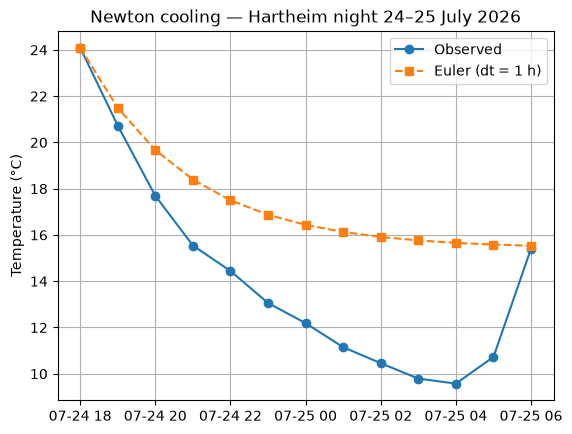

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
HartheimRaw = pd.read_csv('../../processed_data/26030350_hourly.csv', parse_dates=["utc_time"])
HartheimData = HartheimRaw.set_index("utc_time")

def euler_step(y, dt, f):
    return y + dt * f(y)

def euler_solve(y0, t_array, f):
    y = np.zeros(len(t_array))
    y[0] = y0
    for n in range(len(t_array) - 1):
        dt = (t_array[n + 1] - t_array[n]).total_seconds() / 3600
        y[n + 1] = euler_step(y=y[n], dt=dt, f=f)
    return y

def cooling_rate(T, k, T_eq):
    return -k * (T - T_eq)
NightData = HartheimData.loc['2026-07-24 18:00':'2026-07-25 06:00', "temperature_2m"]
T0 = float(NightData.iloc[0])
T_eq = float(NightData.iloc[-1])
k = 0.3
f = lambda T: cooling_rate(T=T, k=k, T_eq=T_eq)
TEuler = euler_solve(y0=T0, t_array=NightData.index, f=f)
plt.plot(NightData.index, NightData.values, 'o-', label='Observed')
plt.plot(NightData.index, TEuler, 's--', label='Euler (dt = 1 h)')
plt.ylabel('Temperature (°C)')
plt.title('Newton cooling — Hartheim night 24–25 July 2026')
plt.legend()
plt.grid(True)
plt.show()

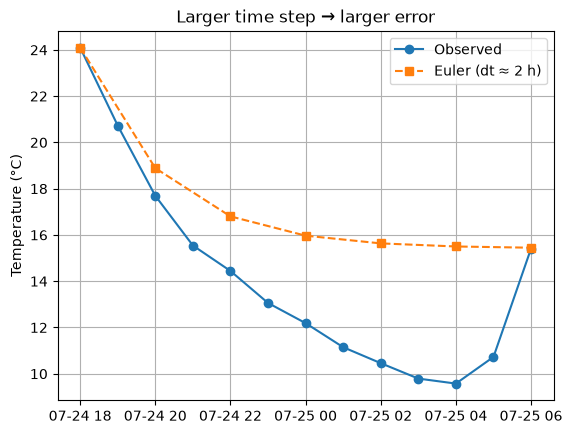

In [16]:
CoarseIndex = NightData.index[::2]
TEulerCoarse = euler_solve(y0=T0, t_array=CoarseIndex, f=f)
plt.plot(NightData.index, NightData.values, 'o-', label='Observed')
plt.plot(CoarseIndex, TEulerCoarse, 's--', label='Euler (dt ≈ 2 h)')
plt.ylabel('Temperature (°C)')
plt.title('Larger time step → larger error')
plt.legend()
plt.grid(True)
plt.show()

## 6. Profiling — how fast is your code?

In **Class 3b** you chose between a `for` loop and **vectorisation**. With only five garden temperatures, both approaches feel instant. But with millions of values, the difference matters.

Python's `time.perf_counter()` returns the current time in seconds with high precision. Wrap code in a timer to measure elapsed time:

```python
import time
start = time.perf_counter()
# ... your code ...
elapsed = time.perf_counter() - start
print(f'Elapsed: {elapsed:.4f} s')
```

Open [`profiling.py`](profiling.py): it repeats the American-cousin conversion from Classes 3a/3b three ways (separate variables, loop, vectorisation), first on 5 values, then on 1 000 000 values.

In [17]:
%run profiling.py

Part 1 — Original exercise (5 locations)

Average (°C): 20.76
Average (°F): 69.368
Class 3a — one variable per location: 0.000043 s

Average (°C): 20.76
Average (°F): 69.368
Class 3b — array + for loop:          0.000027 s

Average (°C): 20.76
Average (°F): 69.36800000000001
Class 3b — vectorisation:             0.000023 s

With only 5 numbers, all three finish in a fraction of a millisecond.
Class 3a cannot even be written for a large dataset: you would need
one named variable per measurement. The next part repeats the same
five values a million times, and times only the approaches that scale.

Part 2 — Same conversion, 1 000 000 measurements

Average (°F): 69.368
Class 3b — array + for loop:          0.0953 s
Average (°F): 69.368
Class 3b — vectorisation:             0.0012 s

Vectorisation is 81× faster than the for-loop on 1 000 000 values.


**Take-home message:** for large numerical arrays, prefer vectorised NumPy operations over Python `for` loops. Functions let you package each approach cleanly and compare them fairly with a timer.